# Practice: Student CGPA Prediction Using Multiple Linear Regression

This practice follows the **same workflow as the house-price linear regression notebook**.

### Minimal changes from the original example

| Original notebook | CGPA practice |
|---|---|
| `LSTAT` | `study_hours` |
| `RM` | `attendance` |
| `MEDV` | `cgpa` |
| House price prediction | Student CGPA prediction |

The dataset contains **several candidate features**. After correlation analysis, we use the **two strongest predictors** so that the workflow remains very close to the original notebook.


## Step 1: Import Libraries and Load Dataset

In [1]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Upload dataset
uploaded = files.upload()

# Load dataset
dataset = pd.read_csv('student_cgpa_synthetic.csv')

print("Dataset loaded successfully.")

Saving student_cgpa_synthetic.csv to student_cgpa_synthetic.csv
Dataset loaded successfully.


In [2]:
dataset.head()

,student_id,study_hours,attendance,assignment_score,midterm_score,sleep_hours,participation_score,cgpa
0,STU1001,12.2,95.6,75.3,64.6,6.3,7.2,3.32
1,STU1002,6.8,91.0,68.0,63.9,6.1,6.5,2.74
2,STU1003,14.0,74.8,71.4,89.2,7.2,8.2,3.28
3,STU1004,14.8,67.0,83.0,76.3,7.1,7.1,2.48
4,STU1005,3.2,52.4,76.0,69.2,5.4,8.7,1.65


In [3]:
print("Dataset shape:", dataset.shape)
print("\nColumns:")
print(dataset.columns)


Dataset shape: (500, 8)

Columns:
Index(['student_id', 'study_hours', 'attendance', 'assignment_score',
       'midterm_score', 'sleep_hours', 'participation_score', 'cgpa'],
      dtype='object')


## Step 2: Exploratory Data Analysis

In [4]:
dataset.describe()

,study_hours,attendance,assignment_score,midterm_score,sleep_hours,participation_score,cgpa
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.00000,500.000000
mean,10.952000,81.459000,75.906200,69.887400,6.79200,6.12000,2.733620
std,3.829871,9.921951,11.118584,12.878076,1.00147,2.16132,0.365139
min,2.000000,50.000000,43.500000,35.000000,4.00000,0.00000,1.650000
25%,8.300000,74.750000,68.700000,61.750000,6.10000,4.60000,2.480000
50%,11.000000,82.100000,76.000000,70.250000,6.80000,6.10000,2.750000
75%,13.325000,87.975000,83.200000,78.600000,7.50000,7.72500,2.990000
max,22.700000,100.000000,100.000000,100.000000,9.00000,10.00000,3.960000


In [5]:
print("Missing values:")
print(dataset.isnull().sum())


Missing values:
student_id             0
study_hours            0
attendance             0
assignment_score       0
midterm_score          0
sleep_hours            0
participation_score    0
cgpa                   0
dtype: int64


## Step 3: Feature Selection

We first examine the correlation between the numerical features and `cgpa`.

A correlation close to **+1** or **-1** indicates a stronger linear relationship.


In [6]:
corr = dataset.corr(numeric_only=True)
print(corr)


                     study_hours  attendance  assignment_score  midterm_score  \
study_hours             1.000000   -0.003879          0.050073      -0.048964   
attendance             -0.003879    1.000000         -0.044267      -0.065113   
assignment_score        0.050073   -0.044267          1.000000      -0.022264   
midterm_score          -0.048964   -0.065113         -0.022264       1.000000   
sleep_hours             0.060158    0.026528         -0.044307       0.003777   
participation_score    -0.031432    0.009956          0.005516      -0.013795   
cgpa                    0.663309    0.499567          0.056282       0.067385   

                     sleep_hours  participation_score      cgpa  
study_hours             0.060158            -0.031432  0.663309  
attendance              0.026528             0.009956  0.499567  
assignment_score       -0.044307             0.005516  0.056282  
midterm_score           0.003777            -0.013795  0.067385  
sleep_hours          

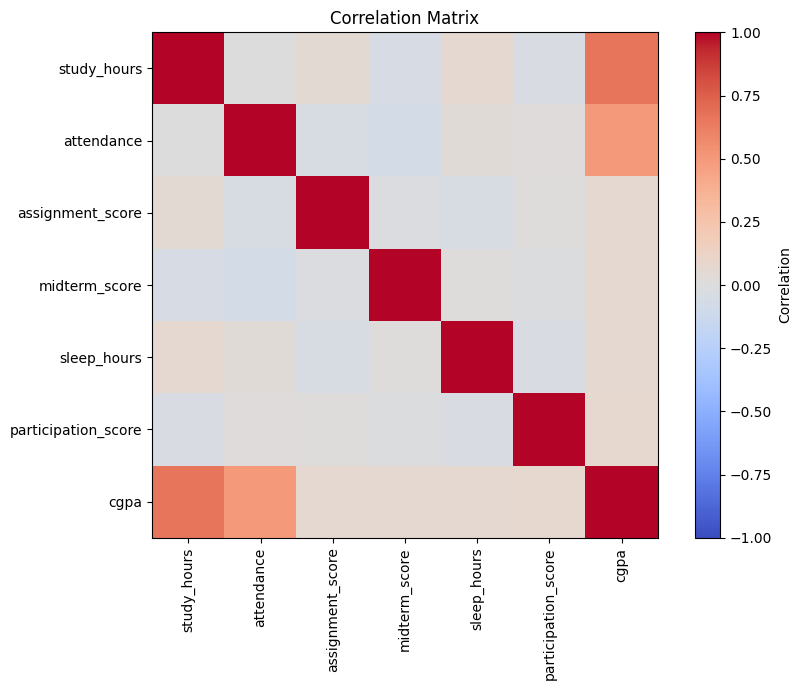

In [7]:
# Visualize correlations of all numerical features

plt.figure(figsize=(9, 7))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


In [8]:
# Get the target and the two features with the highest absolute correlation

top_features = corr['cgpa'].abs().sort_values(ascending=False).head(3)

print("Top correlations with CGPA:")
print(top_features)


Top correlations with CGPA:
cgpa           1.000000
study_hours    0.663309
attendance     0.499567
Name: cgpa, dtype: float64


For this synthetic dataset, `study_hours` and `attendance` are designed to be the strongest predictors of `cgpa`.

We will use these two features so that the exercise remains very similar to the original `LSTAT + RM → MEDV` example.


## Step 4: Multiple Regression

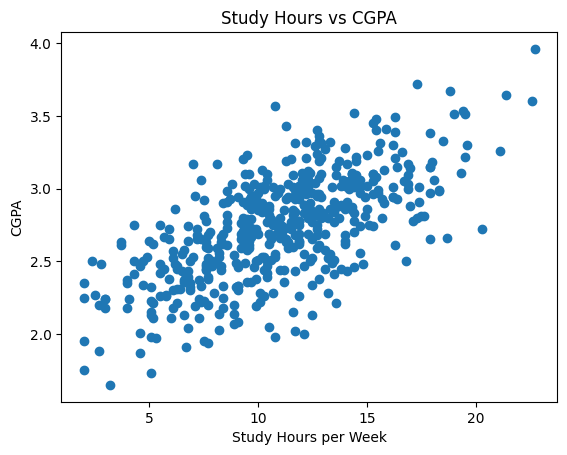

In [9]:
# Relationship between study_hours and cgpa

%matplotlib inline
plt.scatter(dataset['study_hours'], dataset['cgpa'], marker='o')
plt.xlabel('Study Hours per Week')
plt.ylabel('CGPA')
plt.title('Study Hours vs CGPA')
plt.show()


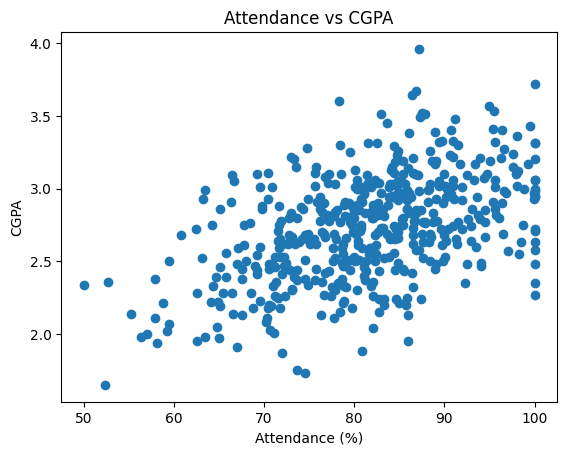

In [10]:
# Relationship between attendance and cgpa

plt.scatter(dataset['attendance'], dataset['cgpa'], marker='o')
plt.xlabel('Attendance (%)')
plt.ylabel('CGPA')
plt.title('Attendance vs CGPA')
plt.show()


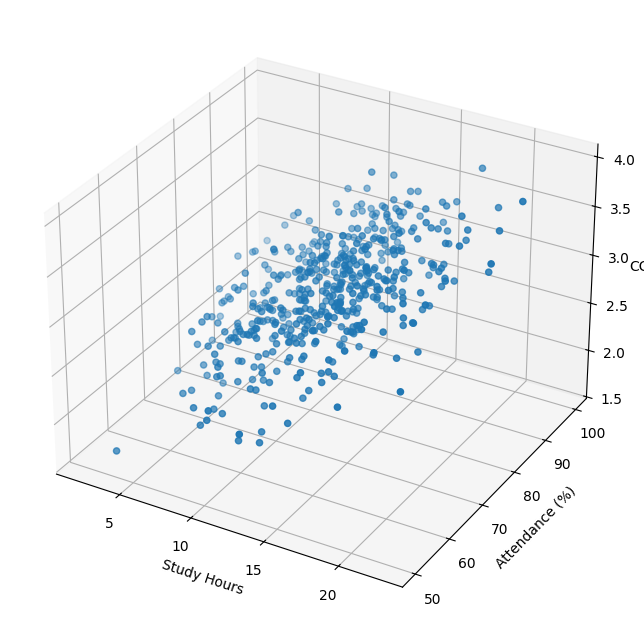

In [11]:
# 3D plot: study_hours + attendance against cgpa

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    dataset['study_hours'],
    dataset['attendance'],
    dataset['cgpa']
)

ax.set_xlabel('Study Hours')
ax.set_ylabel('Attendance (%)')
ax.set_zlabel('CGPA')
plt.show()


## Step 5: Training the Model

Create two DataFrames:

- `x` contains the two selected input features: `study_hours` and `attendance`
- `Y` contains the target: `cgpa`


In [16]:
# Same structure as the original notebook

x = pd.DataFrame(
    np.c_[dataset['study_hours'], dataset['attendance']],
    columns=['study_hours', 'attendance']
)

Y = dataset['cgpa']


In [17]:
# Split the dataset into 70% training and 30% testing

from sklearn.model_selection import train_test_split

x_train, x_test, Y_train, Y_test = train_test_split(
    x,
    Y,
    test_size=0.3,
    random_state=5
)


In [18]:
print("Training input:", x_train.shape)
print("Training target:", Y_train.shape)
print("Testing input:", x_test.shape)
print("Testing target:", Y_test.shape)


Training input: (350, 2)
Training target: (350,)
Testing input: (150, 2)
Testing target: (150,)


In [19]:
# Train the model

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, Y_train)


LinearRegression()

In [20]:
# Make predictions using the testing set

cgpa_pred = model.predict(x_test)

print(cgpa_pred[:10])


[2.92996338 3.0830955  2.63633849 2.54518597 2.80143919 2.84152064
 2.70162481 3.04616084 2.60400213 2.35121555]


## Step 6: Model Evaluation

In [21]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(Y_test, cgpa_pred)
mse = mean_squared_error(Y_test, cgpa_pred)
rmse = np.sqrt(mse)

print("R-squared:", round(r2, 4))
print("MSE:", round(mse, 4))
print("RMSE:", round(rmse, 4))


R-squared: 0.6807
MSE: 0.0452
RMSE: 0.2126


### How to interpret the results

- **R-squared:** closer to **1.0** is better.
- **RMSE:** closer to **0** is better.
- RMSE is in the same unit as CGPA, so it is easy to interpret.


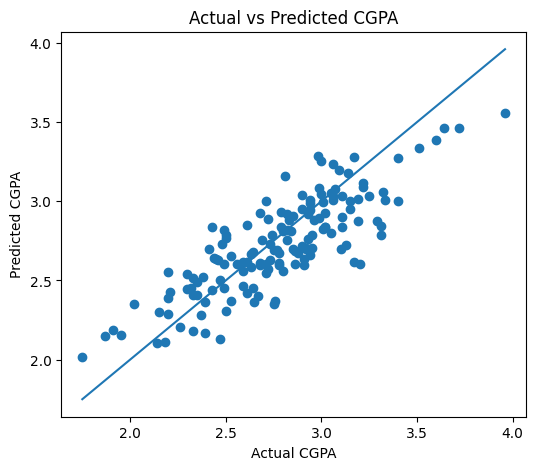

In [22]:
# Compare actual CGPA with predicted CGPA

plt.figure(figsize=(6, 5))
plt.scatter(Y_test, cgpa_pred)

plt.xlabel('Actual CGPA')
plt.ylabel('Predicted CGPA')
plt.title('Actual vs Predicted CGPA')

# Perfect-prediction reference line
min_value = min(Y_test.min(), cgpa_pred.min())
max_value = max(Y_test.max(), cgpa_pred.max())
plt.plot([min_value, max_value], [min_value, max_value])

plt.show()


## Step 7: Save the Model

In [23]:
import joblib

joblib.dump(model, 'cgpa_linear_regression_model.pkl')

print("Model saved as cgpa_linear_regression_model.pkl")


Model saved as cgpa_linear_regression_model.pkl


## Step 8: Try One New Student

The model expects the same two feature names used during training.


In [ ]:
new_student = pd.DataFrame({
    'study_hours': [12.0],
    'attendance': [88.0]
})

predicted_cgpa = model.predict(new_student)[0]

print("Predicted CGPA:", round(predicted_cgpa, 2))


Predicted CGPA: 2.91
